# The Influence of Trading Volume on Short-Term Bitcoin Volatility (2014–2025)

**Kurbatov Daniil Evgenevich — БПАД246 — HSE University — April 2026**

Companion notebook to the research project report. Reproduces every number, table, and figure referenced in the report.

**Tables produced here (numbering follows the report):**
- Table 1 — Descriptive statistics
- Table 2 — Correlations of log volume with volatility proxies
- Table 3 — Stationarity pre-tests (ADF, KPSS)
- Table 5 — Residual diagnostics of the H1 OLS model
- Table 6 — H1 main regression (OLS + Newey–West HAC)
- Table 7 — H1 robustness across four volatility proxies
- Table 8 — H2 Granger causality at multiple lags
- Table 9 — H3 four-model out-of-sample forecasting

**Figures produced here (numbering follows the report):**
- Figure 1 — Bitcoin hourly price and trading volume
- Figure 2 — Three hourly volatility proxies
- Figure 3 — Scatter of log volume vs volatility
- Figure 4 — Random Forest feature importance

**Hypotheses tested (all rejected H0 at the 95% level):**
- H1 (MDH) — contemporaneous volume–volatility association
- H2 (SIAH) — lagged volume Granger-causes volatility
- H3 — adding volume features improves out-of-sample forecasts


## Imports and plot settings

In [39]:
import os
import subprocess
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({
    'font.family':          'serif',
    'axes.grid':            True,
    'grid.alpha':           0.25,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'figure.dpi':           110,
    'savefig.bbox':         'tight',
})
np.random.seed(42)

## Download the dataset from GitHub

The hourly BTC/USD OHLCV series is hosted in the public GitHub repository  
`simonavoprea/Bitcoin_trading`  
(file `btc-hourly-price_2015_2025.csv`). The cell below fetches it with `wget`; if the file is already present locally, the download is skipped.

In [40]:
DATA_URL = 'https://raw.githubusercontent.com/simonavoprea/Bitcoin_trading/main/btc-hourly-price_2015_2025.csv'
DATA_FILE = 'btc-hourly-price_2015_2025.csv'

if not os.path.exists(DATA_FILE):
    subprocess.run(['wget', '-q', DATA_URL, '-O', DATA_FILE], check=True)
print(f'File size: {os.path.getsize(DATA_FILE)/1e6:.2f} MB')

File size: 6.39 MB


---
## Part 1.1 — Load the data

In [41]:
df = pd.read_csv(DATA_FILE)
# Parse timestamp from DATE_STR (dd/mm/YYYY) + HOUR_STR
df['timestamp'] = pd.to_datetime(
    df['DATE_STR'] + ' ' + df['HOUR_STR'].astype(str) + ':00',
    format='%d/%m/%Y %H:%M'
)
df = df.sort_values('timestamp').reset_index(drop=True).set_index('timestamp')
df = df.rename(columns={
    'OPEN_PRICE':  'open',
    'HIGH_PRICE':  'high',
    'LOW_PRICE':   'low',
    'CLOSE_PRICE': 'close',
    'VOLUME_FROM': 'vol_btc',
    'VOLUME_TO':   'vol_usd',
})
print(f'Raw shape: {df.shape}')
print(f'Period:    {df.index.min()}  ->  {df.index.max()}')
print(f'Missing values per column:')
print(df.isnull().sum())
print(f"Duplicates on (date, hour): {df.duplicated(subset=['DATE_STR','HOUR_STR']).sum()}")

Raw shape: (96090, 8)
Period:    2014-11-15 06:00:00  ->  2025-10-31 23:00:00
Missing values per column:
DATE_STR    0
HOUR_STR    0
open        0
high        0
close       0
low         0
vol_btc     0
vol_usd     0
dtype: int64
Duplicates on (date, hour): 0


## Part 1.2 — Feature engineering

In [42]:
# Log return
df['r'] = np.log(df['close'] / df['close'].shift(1))
df['abs_r'] = df['r'].abs()

# Parkinson range volatility (hourly)
df['sigma_P'] = np.sqrt((1/(4*np.log(2))) * (np.log(df['high']/df['low']))**2)

# Garman-Klass range volatility (guard against negative argument)
gk_var = 0.5*(np.log(df['high']/df['low']))**2 - (2*np.log(2)-1)*(np.log(df['close']/df['open']))**2
df['sigma_GK'] = np.where(gk_var > 0, np.sqrt(gk_var.clip(lower=0)), 0.0)

# Log volume
df['V_log'] = np.log1p(df['vol_btc'])

# 24-hour rolling realised volatility, annualised
ANN = np.sqrt(24 * 365)
df['RV_24h'] = df['r'].rolling(24).std() * ANN

# Weekly/monthly RV components (used only in ML later)
df['RV_w'] = df['RV_24h'].rolling(168).mean()
df['RV_m'] = df['RV_24h'].rolling(720).mean()

# Core working sample (for H1/H2): drop rows where any core variable is NaN
core = df.dropna(subset=['r','sigma_P','V_log','RV_24h','abs_r']).copy()
print(f'Raw rows:               {len(df):,}')
print(f'Core working sample:    {len(core):,}')
print(f'Rows lost to rolling:   {len(df)-len(core):,}')

Raw rows:               96,090
Core working sample:    96,066
Rows lost to rolling:   24


## Part 1.3 — Outlier diagnostic (3 × IQR, retained only)

In [43]:
def count_iqr_outliers(x, k=3):
    x = x.dropna()
    q1, q3 = np.quantile(x, [.25, .75])
    iqr = q3 - q1
    return int(((x < q1 - k*iqr) | (x > q3 + k*iqr)).sum())

for col, nm in [('r','log return r'), ('sigma_P','Parkinson sigma^P'), ('V_log','log volume V_log')]:
    print(f'{nm:>25s}: {count_iqr_outliers(core[col]):>6,}')

             log return r:  3,563
        Parkinson sigma^P:  2,577
         log volume V_log:    157


## Part 1.4 — Descriptive statistics (Table 1 in the report)


In [ ]:
def describe(x):
    """Summary statistics for one series: mean, std, min, quartiles, max, skewness, excess kurtosis."""
    x = x.dropna()
    q25, med, q75 = np.quantile(x, [0.25, 0.50, 0.75])
    return (x.mean(), x.std(), x.min(), q25, med, q75, x.max(),
            stats.skew(x), stats.kurtosis(x))

variables = [
    ('Close Price (USD)', core['close']),
    ('Log Return r_t', core['r']),
    ('Volume (BTC)', core['vol_btc']),
    ('Log Volume V_log_t', core['V_log']),
    ('Abs. Return |r_t|', core['abs_r']),
    ('Parkinson sigma^P_t', core['sigma_P']),
    ('Garman-Klass sigma^GK_t', core['sigma_GK']),
    ('Realised Vol. (24h)', core['RV_24h']),
]

print(f'{"Variable":<26s}{"Mean":>11s}{"Std":>11s}{"Min":>10s}{"Q25":>10s}{"Median":>10s}{"Q75":>10s}{"Max":>13s}{"Skew":>8s}{"Kurt":>9s}')

for name, s in variables:
    m, sd, mn, q25, med, q75, mx, sk, kt = describe(s)
    print(f'{name:<26s}{m:>11.4f}{sd:>11.4f}{mn:>10.4f}{q25:>10.4f}{med:>10.4f}{q75:>10.4f}{mx:>13.2f}{sk:>8.2f}{kt:>9.2f}')

## Part 1.5 — Correlation of log volume with volatility proxies (Table 2 in the report)


In [45]:
targets = [('abs_r', '|r|'),
           ('sigma_P', 'sigma_P'),
           ('sigma_GK', 'sigma_GK'),
           ('RV_24h', 'RV_24h')]

print(f'{"Measure":>10s}   {"Pearson":>10s}   {"Spearman":>10s}')
for col, nm in targets:
    x = core['V_log']; y = core[col]
    m = ~(x.isna() | y.isna())
    rp, pp = pearsonr(x[m], y[m])
    rs, ps = spearmanr(x[m], y[m])
    print(f'{nm:>10s}   {rp:>+10.3f}   {rs:>+10.3f}')

   Measure      Pearson     Spearman
       |r|       +0.503       +0.490
   sigma_P       +0.601       +0.727
  sigma_GK       +0.582       +0.716
    RV_24h       +0.497       +0.517


## Part 1.6 — Figure 1: Bitcoin price and trading volume

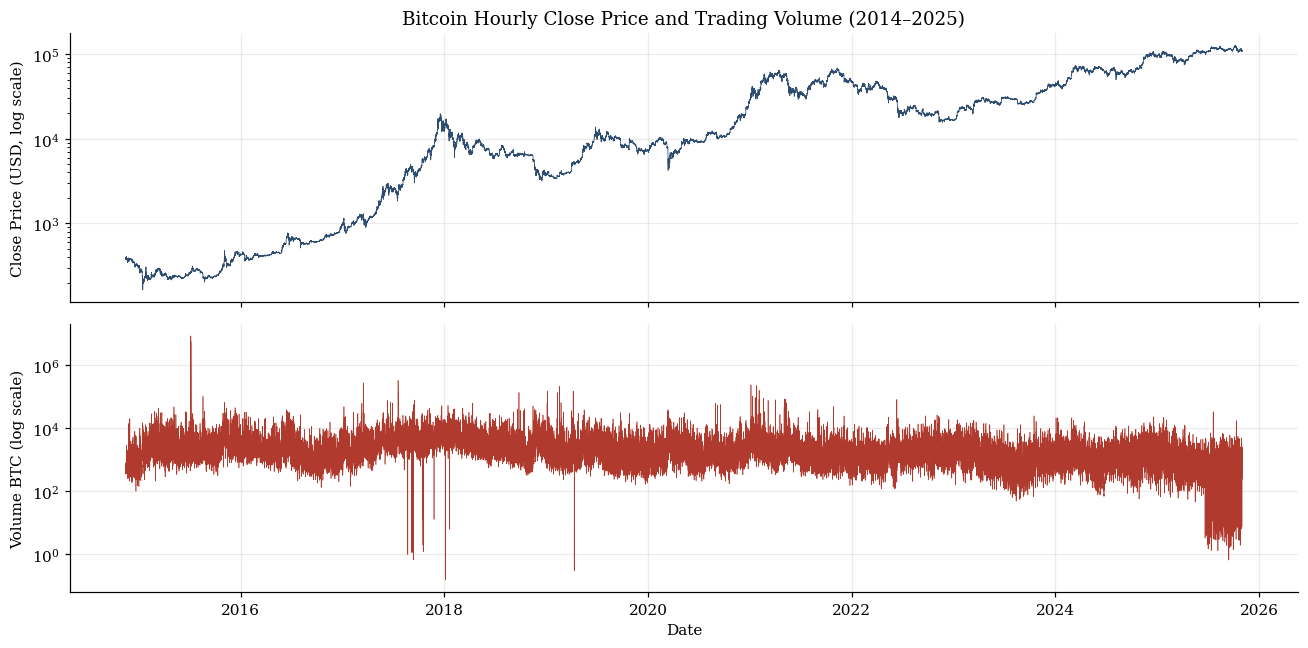

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df.index, df['close'], color='#2E4D70', lw=0.5)
axes[0].set_yscale('log')
axes[0].set_ylabel('Close Price (USD, log scale)')
axes[0].set_title('Bitcoin Hourly Close Price and Trading Volume (2014\u20132025)')

axes[1].plot(df.index, df['vol_btc'].replace(0, np.nan), color='#B03A2E', lw=0.4)
axes[1].set_yscale('log')
axes[1].set_ylabel('Volume BTC (log scale)')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig1_price_volume.pdf')
plt.show()

## Part 1.7 — Figure 2: Hourly volatility proxies

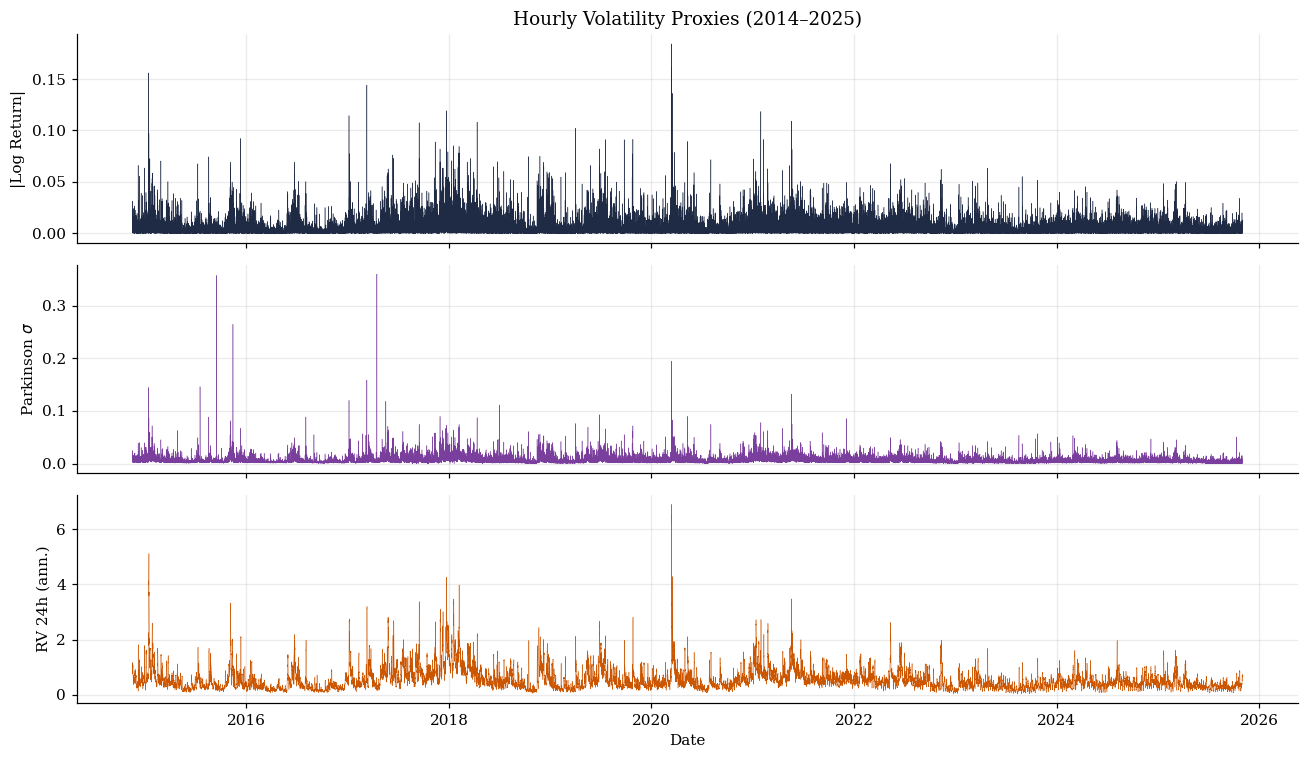

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(core.index, core['abs_r'], color='#1F2A44', lw=0.3)
axes[0].set_ylabel('|Log Return|')
axes[0].set_title('Hourly Volatility Proxies (2014\u20132025)')
axes[1].plot(core.index, core['sigma_P'], color='#7A3E9D', lw=0.3)
axes[1].set_ylabel(r'Parkinson $\sigma$')
axes[2].plot(core.index, core['RV_24h'], color='#CC5500', lw=0.3)
axes[2].set_ylabel('RV 24h (ann.)')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('fig2_volatility_proxies.pdf')
plt.show()

## Part 1.8 — Figure 3: Scatter of log volume vs volatility (5,000-hour sub-sample)

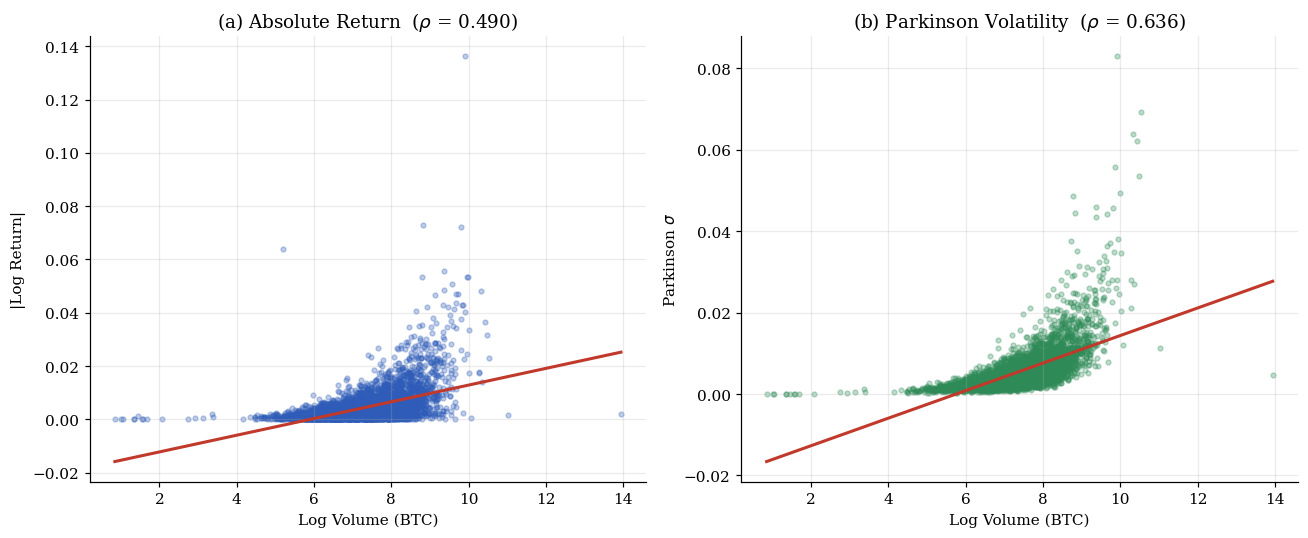

In [48]:
rng = np.random.default_rng(42)
idx = rng.choice(len(core), size=5000, replace=False)
sub = core.iloc[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Absolute return
x = sub['V_log'].values; y = sub['abs_r'].values
rho_a = pearsonr(x, y)[0]
axes[0].scatter(x, y, s=10, alpha=0.3, color='#2E5CB8')
coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xs, np.polyval(coef, xs), color='#C0392B', lw=2)
axes[0].set_xlabel('Log Volume (BTC)')
axes[0].set_ylabel('|Log Return|')
axes[0].set_title(f'(a) Absolute Return  ($\\rho$ = {rho_a:.3f})')

# (b) Parkinson
y = sub['sigma_P'].values
rho_b = pearsonr(x, y)[0]
axes[1].scatter(x, y, s=10, alpha=0.3, color='#2E8B57')
coef = np.polyfit(x, y, 1)
axes[1].plot(xs, np.polyval(coef, xs), color='#C0392B', lw=2)
axes[1].set_xlabel('Log Volume (BTC)')
axes[1].set_ylabel(r'Parkinson $\sigma$')
axes[1].set_title(f'(b) Parkinson Volatility  ($\\rho$ = {rho_b:.3f})')

plt.tight_layout()
plt.savefig('fig3_scatter.pdf')
plt.show()

## Part 1.9 — Stationarity pre-tests (Table 3 in the report)

ADF and KPSS tests on ~10,000 evenly-thinned observations per series. Mixed verdicts (ADF rejects unit-root, KPSS rejects level-stationarity) are common for persistent financial series and motivate the use of Newey–West HAC standard errors in H1.


In [49]:
def adf_tau(y, max_lag=10):
    """Augmented Dickey-Fuller test with a constant; returns the tau statistic (AIC-selected lag)."""
    y = np.asarray(y, dtype=float); y = y[~np.isnan(y)]
    dy = np.diff(y); y_lag = y[:-1]; T = len(dy)
    best = (None, np.inf)

    for p in range(max_lag + 1):
        if T - p - 2 <= 10: continue
        rows = T - p
        X = np.ones((rows, 2 + p))
        X[:, 1] = y_lag[p:]
        Y = dy[p:]

        for k in range(p):
            X[:, 2+k] = dy[p-1-k : T-1-k]
        try:
            beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        except Exception:
            continue

        resid = Y - X @ beta
        sigma2 = (resid**2).sum() / rows
        aic = rows * np.log(sigma2) + 2 * X.shape[1]

        if aic < best[1]:
            XtX_inv = np.linalg.inv(X.T @ X)
            se = np.sqrt(sigma2 * XtX_inv[1,1])
            best = (beta[1]/se, aic)
    return best[0]

def kpss_eta(y):
    """KPSS level-stationarity test (mu version); returns the eta_mu statistic."""
    y = np.asarray(y, dtype=float); y = y[~np.isnan(y)]
    n = len(y); e = y - y.mean(); S = np.cumsum(e)
    L = int(np.floor(4 * (n/100)**0.25))
    gamma0 = (e @ e) / n
    omega2 = gamma0
    for j in range(1, L+1):
        w = 1 - j/(L+1)
        omega2 += 2*w * (e[j:] @ e[:-j]) / n
    return (S @ S) / (n**2 * omega2)

print('Critical values at 5%:  ADF tau = -2.86   |   KPSS eta = 0.463')
print(f'{"Series":>12s}  {"ADF tau":>12s}  {"Verdict":>12s}  {"KPSS eta":>12s}  {"Verdict":>12s}')

for col in ['r','abs_r','sigma_P','RV_24h','V_log']:
    s = core[col].dropna()
    step = max(1, len(s) // 10000)
    thin = s.iloc[::step].values
    tau = adf_tau(thin, max_lag=10)
    eta = kpss_eta(thin)
    adf_v  = 'Stationary' if tau < -2.86 else 'Non-stat.'
    kpss_v = 'Stationary' if eta < 0.463 else 'Non-stat.'
    print(f'{col:>12s}  {tau:>+12.3f}  {adf_v:>12s}  {eta:>12.3f}  {kpss_v:>12s}')

Critical values at 5%:  ADF tau = -2.86   |   KPSS eta = 0.463
      Series       ADF tau       Verdict      KPSS eta       Verdict
           r      -103.034    Stationary         0.231    Stationary
       abs_r       -21.804    Stationary         3.329     Non-stat.
     sigma_P       -18.690    Stationary         3.920     Non-stat.
      RV_24h       -15.328    Stationary         4.505     Non-stat.
       V_log       -13.830    Stationary        29.055     Non-stat.


---
## Part 2 — Hypothesis 1 (MDH): OLS with Newey–West HAC standard errors

$$ \sigma^P_t = \alpha + \beta_1 V^{\log}_t + \beta_2 \sigma^P_{t-1} + \beta_3 |r_{t-1}| + \varepsilon_t $$

- $H_0: \beta_1 = 0$ (volume unrelated to contemporaneous volatility)
- $H_1: \beta_1 \neq 0$ (the MDH-consistent alternative)
- Newey–West HAC bandwidth: $L = \lfloor 4(T/100)^{2/9}\rfloor$ (Andrews 1991 rule)

In [50]:
def hac_bandwidth(T):
    """Andrews (1991) rule-of-thumb bandwidth for the Newey-West HAC estimator."""
    return int(np.floor(4 * (T/100)**(2/9)))

def ols_hac(y, X):
    """OLS with Newey-West HAC covariance. Returns (beta, SE, R2, T, L, Durbin-Watson)."""
    y = np.asarray(y, dtype=float); X = np.asarray(X, dtype=float)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    T, K = X.shape
    L = hac_bandwidth(T)
    XtX_inv = np.linalg.inv(X.T @ X)
    u = X * resid[:, None]
    S = u.T @ u / T

    for j in range(1, L+1):
        w = 1 - j/(L+1)
        G = u[j:].T @ u[:-j] / T
        S += w * (G + G.T)

    V = T * XtX_inv @ S @ XtX_inv
    se = np.sqrt(np.diag(V))
    r2 = 1 - ((y - X@beta)**2).sum() / ((y - y.mean())**2).sum()
    dw = ((np.diff(resid))**2).sum() / (resid**2).sum()
    return beta, se, r2, T, L, dw

### H1 main regression (Table 6 in the report)

$$ \sigma^P_t = \alpha + \beta_1 V^{\log}_t + \beta_2 \sigma^P_{t-1} + \beta_3 |r_{t-1}| + \varepsilon_t $$

Null hypothesis: $\beta_1 = 0$ (volume does not matter). Estimated with OLS; standard errors are Newey–West HAC with Andrews (1991) bandwidth $L = 18$.


In [51]:
core['sigma_P_lag1'] = core['sigma_P'].shift(1)
core['abs_r_lag1'] = core['abs_r'].shift(1)

m = core[['sigma_P','V_log','sigma_P_lag1','abs_r_lag1']].dropna()
y = m['sigma_P'].values
ones = np.ones(len(m))

# Baseline (no volume)
Xb = np.column_stack([ones, m['sigma_P_lag1'], m['abs_r_lag1']])
bb, seb, r2b, Tb, Lb, dwb = ols_hac(y, Xb)

print(f'Baseline:  N={Tb}  L_HAC={Lb}  R2={r2b:.4f}  DW={dwb:.3f}')
print(f'  intercept    = {bb[0]:+.5f}  (SE {seb[0]:.5f})')
print(f'  sigma_P_lag1 = {bb[1]:+.5f}  (SE {seb[1]:.5f})')
print(f'  |r|_lag1     = {bb[2]:+.5f}  (SE {seb[2]:.5f})')

# Full (with volume)
Xf = np.column_stack([ones, m['V_log'], m['sigma_P_lag1'], m['abs_r_lag1']])
bf, sef, r2f, Tf, Lf, dwf = ols_hac(y, Xf)

print(f'\nFull H1:   N={Tf}  L_HAC={Lf}  R2={r2f:.4f}  DW={dwf:.3f}')
print(f'  intercept    = {bf[0]:+.5f}  (SE {sef[0]:.5f})')
print(f'  V_log        = {bf[1]:+.5f}  (SE {sef[1]:.5f})')
print(f'  sigma_P_lag1 = {bf[2]:+.5f}  (SE {sef[2]:.5f})')
print(f'  |r|_lag1     = {bf[3]:+.5f}  (SE {sef[3]:.5f})')

tstat = bf[1]/sef[1]
lo, hi = bf[1]-1.96*sef[1], bf[1]+1.96*sef[1]
print(f'\n>>> Test statistic on V_log: t = {tstat:+.2f}')
print(f'>>> 95% CI: [{lo:+.5f}, {hi:+.5f}]')
print(f'>>> Delta R2 = {r2f - r2b:+.4f}')
print(f'>>> Decision: reject H0 (volume matters for contemporaneous volatility)')

Baseline:  N=96065  L_HAC=18  R2=0.2903  DW=2.271
  intercept    = +0.00248  (SE 0.00018)
  sigma_P_lag1 = +0.46939  (SE 0.08187)
  |r|_lag1     = +0.07768  (SE 0.06007)

Full H1:   N=96065  L_HAC=18  R2=0.4452  DW=1.938
  intercept    = -0.01585  (SE 0.00046)
  V_log        = +0.00266  (SE 0.00008)
  sigma_P_lag1 = +0.29907  (SE 0.05775)
  |r|_lag1     = +0.03279  (SE 0.03789)

>>> Test statistic on V_log: t = +33.35
>>> 95% CI: [+0.00251, +0.00282]
>>> Delta R2 = +0.1549
>>> Decision: reject H0 (volume matters for contemporaneous volatility)


### Residual diagnostics on the H1 full model (Table 5 in the report)

Three classical OLS assumptions are checked on the H1 residuals:
- **Jarque–Bera** — tests normality ($H_0$: residuals are normal)
- **Breusch–Pagan** — tests homoscedasticity ($H_0$: constant variance)
- **Durbin–Watson** — tests first-order autocorrelation

If JB or BP are rejected, classical OLS standard errors are unreliable — Newey–West HAC is the correct remedy.


In [ ]:
# Residuals from the H1 full-model fit computed in the cell above
resid = y - Xf @ bf
n = len(resid)

# Durbin-Watson
dw = ((np.diff(resid))**2).sum() / (resid**2).sum()

# Jarque-Bera (manual): JB = (n/6) * (skew^2 + (kurt-3)^2 / 4)
e = resid - resid.mean()
sk = ((e**3).mean()) / ((e**2).mean())**1.5
ku = ((e**4).mean()) / ((e**2).mean())**2
jb = (n/6) * (sk**2 + ((ku - 3)**2)/4)
jb_p = 1 - stats.chi2.cdf(jb, 2)

# Breusch-Pagan (manual): e^2 ~ X, LM = n * R2_aux ~ chi2(K-1)
e_sq = resid**2
b_aux, *_ = np.linalg.lstsq(Xf, e_sq, rcond=None)
ss_reg = ((Xf @ b_aux - e_sq.mean())**2).sum()
ss_tot = ((e_sq - e_sq.mean())**2).sum()
r2_aux = ss_reg / ss_tot
bp_stat = n * r2_aux
bp_df = Xf.shape[1] - 1
bp_p = 1 - stats.chi2.cdf(bp_stat, bp_df)

print(f'N residuals    : {n:,}')
print(f'Skewness       : {sk:+.3f}')
print(f'Kurtosis (raw) : {ku:.2f}   (excess = {ku-3:+.2f})')
print(f'Jarque-Bera    : JB = {jb:,.1f}   p = {jb_p:.3g}')
print(f'Breusch-Pagan  : LM = {bp_stat:,.1f}   df = {bp_df}   p = {bp_p:.3g}')
print(f'Durbin-Watson  : DW = {dw:.4f}')
print()
print('Verdict: normality and homoscedasticity are both rejected outright.')
print('Durbin-Watson is close to its null value of 2, but higher-order serial')
print('correlation in persistent volatility series remains likely, so Newey-West')
print('HAC (heteroscedasticity- and autocorrelation-robust) standard errors are preferred.')


### Non-parametric complement to H1: Welch $t$-test and Mann–Whitney $U$

Because residuals are strongly non-normal and heteroscedastic, we confirm the H1 result with two distribution-free tests. The sample is split at the 25th and 75th percentiles of log volume into a low-volume regime and a high-volume regime.


In [53]:
q25, q75 = core['V_log'].quantile([0.25, 0.75])
low = core.loc[core['V_log'] <= q25, 'sigma_P'].dropna().values
high = core.loc[core['V_log'] >= q75, 'sigma_P'].dropna().values

# Welch t (one-sided: high > low)
t_welch, p_welch = stats.ttest_ind(low, high, equal_var=False, alternative='less')

# Mann-Whitney U (one-sided: high > low)
u_stat, p_mw = stats.mannwhitneyu(low, high, alternative='less')

# Cohen d (pooled)
pooled = np.sqrt((low.var(ddof=1) + high.var(ddof=1)) / 2)
cohen_d = (high.mean() - low.mean()) / pooled

print(f'{"Low-volume (q25)":<20s}  N = {len(low):>6,}   mean sigma_P = {low.mean():.5f}')
print(f'{"High-volume (q75)":<20s}  N = {len(high):>6,}   mean sigma_P = {high.mean():.5f}')
print()
print(f'Welch t-test (one-sided H1: high > low): t = {t_welch:+.2f} p = {p_welch:.3g}')
print(f'Mann-Whitney U (one-sided H1: high > low): U = {u_stat:,.0f} p = {p_mw:.3g}')
print(f'Cohen d (effect size): {cohen_d:+.3f}  ("very large" if |d| >= 0.8)')
print()
print('>>> Both non-parametric tests reject H0 decisively, in agreement with OLS/HAC.')


Low-volume (q25)      N = 24,017   mean sigma_P = 0.00233
High-volume (q75)     N = 24,017   mean sigma_P = 0.01042

Welch t-test (one-sided H1: high > low): t = -150.10 p = 0
Mann-Whitney U (one-sided H1: high > low): U = 18,236,138 p = 0
Cohen d (effect size): +1.370  ("very large" if |d| >= 0.8)

>>> Both non-parametric tests reject H0 decisively, in agreement with OLS/HAC.


### H1 robustness across four volatility proxies (Table 7 in the report)

The same regression is re-run with four different dependent variables. If the volume coefficient stays positive and significant, the H1 result is not an artefact of any single volatility definition.


In [54]:
print(f'{"Dep var":>15s}  {"beta1":>10s}  {"SE":>10s}  {"t":>8s}  {"Delta R2":>10s}  {"N":>8s}')

for dep, nm in [('sigma_P','Parkinson'),
                ('abs_r','|r|'),
                ('sigma_GK','Garman-Klass'),
                ('RV_24h','RV_24h')]:
    core[f'{dep}_lag1'] = core[dep].shift(1)

    #For |r| regression, don't double-include |r|_lag1 (it IS the lag of y)
    if dep == 'abs_r':
        mm = core[[dep,'V_log',f'{dep}_lag1']].dropna()
        oo = np.ones(len(mm))
        Xfull = np.column_stack([oo, mm['V_log'], mm[f'{dep}_lag1']])
        Xbase = np.column_stack([oo, mm[f'{dep}_lag1']])
    else:
        mm = core[[dep,'V_log',f'{dep}_lag1','abs_r_lag1']].dropna()
        oo = np.ones(len(mm))
        Xfull = np.column_stack([oo, mm['V_log'], mm[f'{dep}_lag1'], mm['abs_r_lag1']])
        Xbase = np.column_stack([oo, mm[f'{dep}_lag1'], mm['abs_r_lag1']])
    yv = mm[dep].values

    b, s, r2, T_, _, _ = ols_hac(yv, Xfull)
    _, _, r2_b, _, _, _ = ols_hac(yv, Xbase)

    print(f'{nm:>15s}  {b[1]:>+10.5f}  {s[1]:>10.5f}  {b[1]/s[1]:>+8.2f}  {r2-r2_b:>+10.4f}  {T_:>8,}')

        Dep var       beta1          SE         t    Delta R2         N
      Parkinson    +0.00266     0.00008    +33.35     +0.1549    96,065
            |r|    +0.00291     0.00006    +47.06     +0.1679    96,065
   Garman-Klass    +0.00249     0.00008    +32.15     +0.1317    96,065
         RV_24h    +0.01511     0.00052    +29.01     +0.0009    96,065


---
## Part 3 — Hypothesis 2 (SIAH): Granger causality (Table 8 in the report)

$$ \sigma^P_t = c + \sum_{i=1}^p \phi_i \sigma^P_{t-i} + \sum_{i=1}^p \psi_i V^{\log}_{t-i} + u_t $$

Null hypothesis: all $\psi_i = 0$ (lagged volume does not help predict volatility). Tested at lags 1, 3, 6, 12, 24 (the BIC-optimal lag is 24). The reverse direction ($\sigma^P \Rightarrow V^{\log}$) is also tested.


In [55]:
def granger_test(y, x, p):
    """Granger F-test: does x help predict y beyond y's own p lags? Returns (F, p-value, N)."""
    y = np.asarray(y, dtype=float); x = np.asarray(x, dtype=float)
    T = len(y); n = T - p
    Y  = y[p:]
    Xr = np.ones((n, 1 + p))
    Xu = np.ones((n, 1 + 2*p))

    for k in range(p):
        Xr[:, 1+k] = y[p-1-k : T-1-k]
        Xu[:, 1+k] = y[p-1-k : T-1-k]
        Xu[:, 1+p+k] = x[p-1-k : T-1-k]

    br, *_ = np.linalg.lstsq(Xr, Y, rcond=None)
    bu, *_ = np.linalg.lstsq(Xu, Y, rcond=None)
    rss_r = ((Y - Xr@br)**2).sum()
    rss_u = ((Y - Xu@bu)**2).sum()

    F = ((rss_r - rss_u)/p) / (rss_u/(n - (1+2*p)))
    pval = 1 - stats.f.cdf(F, p, n - (1+2*p))

    return F, pval, n

gc = core[['sigma_P','V_log']].dropna()
print(f'N available for Granger test: {len(gc):,}')
print(f'\n{"Lag p":>6s}  {"V->sigP F":>12s}  {"p-val":>10s}  {"sigP->V F":>12s}  {"p-val":>10s}  {"N":>8s}')

for p in [1, 3, 6, 12, 24]:
    F1, p1, n1 = granger_test(gc['sigma_P'].values, gc['V_log'].values,  p)
    F2, p2, _  = granger_test(gc['V_log'].values, gc['sigma_P'].values, p)

    print(f'{p:>6d}  {F1:>12.2f}  {p1:>10.3g}  {F2:>12.2f}  {p2:>10.3g}  {n1:>8,}')

N available for Granger test: 96,066

 Lag p     V->sigP F       p-val     sigP->V F       p-val         N
     1       2525.49    1.11e-16         11.00    0.000911    96,065
     3        312.26    1.11e-16         71.42    1.11e-16    96,063
     6        127.64    1.11e-16         26.81    1.11e-16    96,060
    12         77.06    1.11e-16         25.53    1.11e-16    96,054
    24         39.98    1.11e-16         25.56    1.11e-16    96,042


---
## Part 4 — Hypothesis 3 (out-of-sample forecasting): four-model comparison (Table 9 in the report)

$H_0$: Adding volume features does **not** improve out-of-sample forecasting of $\sigma^P_{t+1}$ ($\Delta R^2 \leq 0$).  
$H_1$: Adding volume features **does** improve out-of-sample forecasting ($\Delta R^2 > 0$).

Target: one-step-ahead Parkinson volatility $\sigma^P_{t+1}$.  Feature set (10 predictors):

- Volatility lags: $\sigma^P_{t-1}, \sigma^P_{t-24}, \sigma^P_{t-168}$
- Return features: $r_{t-1}, |r_{t-1}|$
- Volume features: $V^{\log}_t, V^{\log}_{t-1}, V^{\log}_{t-24}$
- Multi-horizon RV: $RV^{(w)}_t, RV^{(m)}_t$

Strictly chronological split (no look-ahead bias):  
**Train** 2015-01-01 → 2022-12-31 | **Val** 2023 | **Test** 2024-01-01 → 2025-10-31

Four models are compared: Naive random walk, OLS with volume, Random Forest without volume, and Random Forest with volume. The formal H3 test is a bootstrap 95% CI on $\Delta R^2 = R^2_{\text{RF full}} - R^2_{\text{RF no-vol}}$.


In [56]:
feat = core.copy()
feat['sigma_P_lag1'] = feat['sigma_P'].shift(1)
feat['sigma_P_lag24'] = feat['sigma_P'].shift(24)
feat['sigma_P_lag168'] = feat['sigma_P'].shift(168)
feat['abs_r_lag1'] = feat['abs_r'].shift(1)
feat['r_lag1'] = feat['r'].shift(1)
feat['V_log_lag1'] = feat['V_log'].shift(1)
feat['V_log_lag24'] = feat['V_log'].shift(24)

# RV_w and RV_m are already in core (computed in the feature-engineering cell above)
feat['y'] = feat['sigma_P'].shift(-1)    # target = sigma_P at t+1

feature_cols = ['sigma_P_lag1','sigma_P_lag24','sigma_P_lag168',
                'abs_r_lag1','r_lag1',
                'V_log','V_log_lag1','V_log_lag24',
                'RV_w','RV_m']

feat = feat.dropna(subset=feature_cols + ['y','sigma_P']).copy()

train = feat.loc['2015-01-01':'2022-12-31']
val = feat.loc['2023-01-01':'2023-12-31']
test = feat.loc['2024-01-01':'2025-12-31']

print(f'Train: N = {len(train):,}')
print(f'Val:   N = {len(val):,}')
print(f'Test:  N = {len(test):,}')


Train: N = 70,128
Val:   N = 8,760
Test:  N = 16,079


### Fit four forecasting models


In [57]:
def metrics(y_true, y_pred):
    """Return (RMSE, MAE, R2) for a set of predictions."""
    return (np.sqrt(mean_squared_error(y_true, y_pred)),
            mean_absolute_error(y_true, y_pred),
            r2_score(y_true, y_pred))

def ols_fit(X_tr, y_tr, X_te):
    """Fit OLS with an intercept on the training set; return test-set predictions."""
    Xt = np.column_stack([np.ones(len(X_tr)), X_tr])
    beta, *_ = np.linalg.lstsq(Xt, y_tr, rcond=None)
    return np.column_stack([np.ones(len(X_te)), X_te]) @ beta

results = {}
preds_test = {}

# 1. Naive: y_hat_{t+1} = sigma_P_t
for name, ss in [('val', val), ('test', test)]:
    results.setdefault('Naive', {})[name] = metrics(ss['y'].values, ss['sigma_P'].values)
preds_test['Naive'] = test['sigma_P'].values

# 2. OLS with volume
vol_cols = ['sigma_P_lag1','abs_r_lag1','V_log','V_log_lag1']

for name, ss in [('val', val), ('test', test)]:
    yh = ols_fit(train[vol_cols].values, train['y'].values, ss[vol_cols].values)
    results.setdefault('OLS-vol', {})[name] = metrics(ss['y'].values, yh)

    if name == 'test':
        preds_test['OLS-vol'] = yh

# 3. Random Forest without volume
rf_cols_nov = ['sigma_P_lag1','sigma_P_lag24','sigma_P_lag168', 'abs_r_lag1','r_lag1','RV_w','RV_m']

rf_nov = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf_nov.fit(train[rf_cols_nov].values, train['y'].values)

for name, ss in [('val', val), ('test', test)]:
    yh = rf_nov.predict(ss[rf_cols_nov].values)
    results.setdefault('RF-noV', {})[name] = metrics(ss['y'].values, yh)

    if name == 'test':
        preds_test['RF-noV'] = yh

# 4. Random Forest with volume (full model)
rf_full = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf_full.fit(train[feature_cols].values, train['y'].values)

for name, ss in [('val', val), ('test', test)]:
    yh = rf_full.predict(ss[feature_cols].values)
    results.setdefault('RF-full', {})[name] = metrics(ss['y'].values, yh)

    if name == 'test':
        preds_test['RF-full'] = yh

# Target vector for the bootstrap cell below
y_test = test['y'].values

print(f'{"Model":<12}  {"RMSE_val":>10} {"MAE_val":>10} {"R2_val":>8}' f'{"RMSE_te":>10} {"MAE_te":>10} {"R2_te":>8}')

for m in ['Naive','OLS-vol','RF-noV','RF-full']:
    v = results[m]['val']; t = results[m]['test']
    print(f'{m:<12}  {v[0]:>10.5f} {v[1]:>10.5f} {v[2]:>+8.3f}' f'{t[0]:>10.5f} {t[1]:>10.5f} {t[2]:>+8.3f}')

Model           RMSE_val    MAE_val   R2_val   RMSE_te     MAE_te    R2_te
Naive            0.00317    0.00171   -0.056   0.00312    0.00186   +0.136
OLS-vol          0.00284    0.00180   +0.153   0.00301    0.00187   +0.193
RF-noV           0.00286    0.00173   +0.141   0.00295    0.00187   +0.227
RF-full          0.00269    0.00154   +0.239   0.00275    0.00167   +0.327


### Bootstrap 95% CI for $\Delta R^2$ — formal test of H3

The H3 test is a bootstrap 95% CI on $\Delta R^2 = R^2_{\text{RF full}} - R^2_{\text{RF no-vol}}$:
we resample $(y, \hat y_{\text{full}}, \hat y_{\text{no-vol}})$ triples with $B = 500$ and
reject $H_0$ if the lower bound of the interval lies above zero.


In [58]:
B = 500
rng = np.random.default_rng(42)
N = len(y_test)

dr2 = np.empty(B)

for b in range(B):
    idx = rng.integers(0, N, N)
    yt = y_test[idx]
    dr2[b] = r2_score(yt, preds_test['RF-full'][idx]) - r2_score(yt, preds_test['RF-noV'][idx])

point = r2_score(y_test, preds_test['RF-full']) - r2_score(y_test, preds_test['RF-noV'])
lo, hi = np.percentile(dr2, [2.5, 97.5])

verdict = 'REJECT H0 (volume helps)' if lo > 0 else 'fail to reject'

print(f'Delta R^2 (RF-full - RF-noV)')
print(f'  point estimate  = {point:+.4f}')
print(f'  bootstrap mean  = {dr2.mean():+.4f}')
print(f'  95% CI          = [{lo:+.4f}, {hi:+.4f}]')
print(f'  verdict         = {verdict}')

Delta R^2 (RF-full - RF-noV)
  point estimate  = +0.1004
  bootstrap mean  = +0.1005
  95% CI          = [+0.0871, +0.1129]
  verdict         = REJECT H0 (volume helps)


### Figure 4: Random Forest feature importance

Mean decrease in impurity. Volume features (red) vs volatility/return features (blue). The three volume features together account for ~26.5% of total importance.


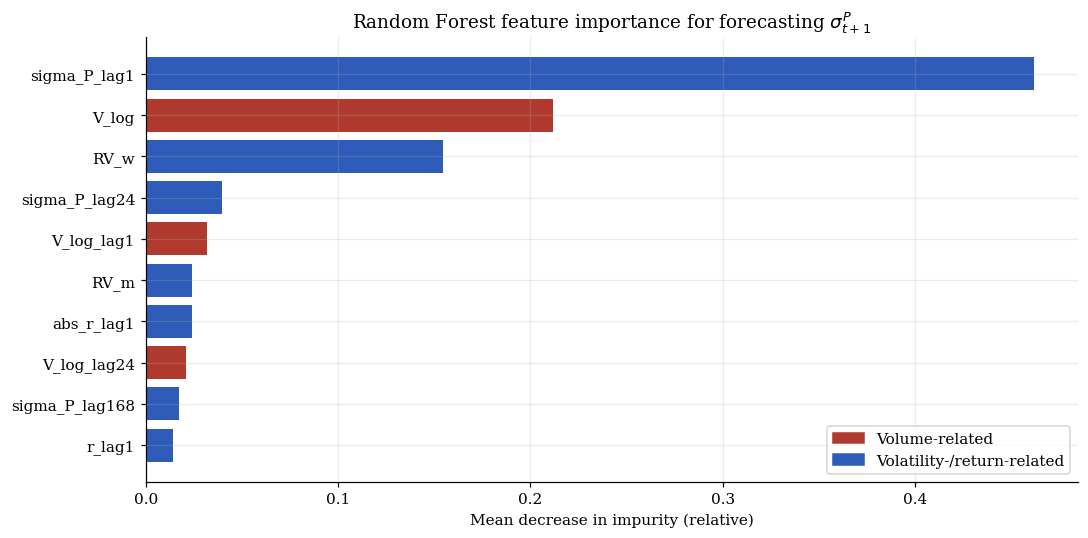


Feature importances (sorted):
  sigma_P_lag1          0.4616
  V_log                 0.2117
  RV_w                  0.1547
  sigma_P_lag24         0.0395
  V_log_lag1            0.0321
  RV_m                  0.0242
  abs_r_lag1            0.0239
  V_log_lag24           0.0210
  sigma_P_lag168        0.0172
  r_lag1                0.0142

Volume-feature importance total: 0.265


In [59]:
importances = pd.Series(rf_full.feature_importances_, index=feature_cols).sort_values()
vol_mask = importances.index.str.contains('V_log')
colors = ['#B03A2E' if v else '#2E5CB8' for v in vol_mask]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel('Mean decrease in impurity (relative)')
ax.set_title(r'Random Forest feature importance for forecasting $\sigma^P_{t+1}$')
ax.legend(handles=[Patch(color='#B03A2E', label='Volume-related'), Patch(color='#2E5CB8', label='Volatility-/return-related')], loc='lower right')

plt.tight_layout()
plt.savefig('fig_importance.pdf')
plt.show()

print('\nFeature importances (sorted):')

for f, v in importances[::-1].items():
    print(f'  {f:<20s}  {v:.4f}')
print(f'\nVolume-feature importance total: {importances[vol_mask].sum():.3f}')

---
## Summary of findings

1. **H1 (MDH) supported.** $\hat\beta_1 = 0.00266$ (HAC SE 0.00008, $t = 33.4$, $p < 0.001$); 95% HAC CI $[+0.00251, +0.00282]$. $\Delta R^2 = +0.155$. Effect is robust across four volatility proxies. Non-parametric Welch and Mann–Whitney tests on volume-quartile splits confirm the conclusion with Cohen's $d = +1.37$ (very large effect).

2. **H2 (SIAH) supported.** Granger-causality $V^{\log} \Rightarrow \sigma^P$ is significant at every tested lag (BIC-optimal $p^* = 24$: $F = 40.0$, $p < 0.001$). Reverse causality is also significant but more than two orders of magnitude weaker at lag 1.

3. **H3 (out-of-sample forecasting) supported.** Full Random Forest achieves $R^2 = +0.327$ on 2024–2025 vs $+0.227$ for the same model without volume features; bootstrap 95% CI for $\Delta R^2 = +0.100$ is $[+0.087, +0.113]$, excluding zero.

**Overall conclusion:** trading volume is a first-order explanatory variable for short-term Bitcoin volatility. Both the contemporaneous (MDH) and lead–lag (SIAH) channels operate at the hourly frequency, and the relationship is strong enough to produce a statistically significant out-of-sample forecast improvement.
